In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import json
import os
import time


In [17]:
# parameter setting
batch_size = 32
learning_rate = 0.001
epoch = 10

# GPU setting
cuda_available = torch.cuda.is_available()
device = torch.device('cuda' if cuda_available else 'cpu')

print('Current cuda device is', device)


Current cuda device is cuda


In [18]:
# Experiment setting
EXPERIMENT_NAME = 'No Padding'
EXPERIMENT_SLUG = 'no_padding'
EXPERIMENT_CONFIG = {"filters": [32, 64], "kernel_size": 3, "stride": 1, "padding": 0, "fc_hidden": 1000}

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULT_DIR = '/content/drive/MyDrive/experiment_results'
except ModuleNotFoundError:
    RESULT_DIR = './experiment_results'

RESULT_PATH = os.path.join(RESULT_DIR, 'no_padding.json')
print('Result directory:', RESULT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Result directory: /content/drive/MyDrive/experiment_results


In [19]:
# dataset 불러오기
train_data = datasets.MNIST(root = './data/train/',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=True)
test_data = datasets.MNIST(root = './data/test/',
                           train=False,
                           transform=transforms.ToTensor(),
                           download=True)

train_loader=DataLoader(dataset=train_data,
                        batch_size=batch_size,
                        shuffle=True)

test_loader=DataLoader(dataset=test_data,
                       batch_size=batch_size,
                       shuffle=True)


In [20]:
# Deep Learning Model setting
class Convolution_Neural_Networks(nn.Module):
  def __init__(self):
    super(Convolution_Neural_Networks, self).__init__()

    # CNN 하이퍼파라미터를 생성자 내부에 명시적으로 고정
    # [conv1] 입력 -> (1, 28, 28) -> (32, 26, 26)
    self.conv1=nn.Conv2d(in_channels = 1, out_channels = 32, kernel_size = 3, stride = 1, padding = 0)
    # [conv2] 입력 -> (32, 13, 13) -> (64, 11, 11)
    self.conv2=nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 0)

    # dropout: 학습 중 일부 채널을 0으로 만들어 과적합을 줄이려는 기법
    self.dropout=nn.Dropout2d(0.25) # eval()에서 적용 X
    self.relu=nn.ReLU()
    self.max_pooling=nn.MaxPool2d(kernel_size=2)
    self.fc_input = 1600
    self.fc1=nn.Linear(1600,1000)
    # 최종 정답 레이어는 10가지
    self.fc2=nn.Linear(1000,10)

  def forward(self, x):
    x=self.conv1(x) # (1, 28, 28) -> (32, 26, 26)
    x=self.relu(x) # (32, 26, 26)
    x=self.max_pooling(x) # (32, 26, 26) -> (32, 13, 13)

    x=self.conv2(x) # (32, 13, 13) -> (64, 11, 11)
    x=self.relu(x) # (64, 11, 11)
    x=self.max_pooling(x) # (64, 11, 11) -> (64, 5, 5)

    x=self.dropout(x)
    x=torch.flatten(x,1) # (64, 5, 5) -> 1차원(1600)

    x=self.fc1(x) # 1600 -> 1000
    x=self.relu(x) # 1000
    x=self.fc2(x) # 1000 -> 10
    output = F.log_softmax(x, dim=1)
    return output


In [21]:
# model에 GPU/CPU 적용
model = Convolution_Neural_Networks().to(device)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

parameter_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Experiment:', EXPERIMENT_NAME)
print('Config:', EXPERIMENT_CONFIG)
print('Trainable parameters:', f'{parameter_count:,}')
print('FC input size:', model.fc_input)


Experiment: No Padding
Config: {'filters': [32, 64], 'kernel_size': 3, 'stride': 1, 'padding': 0, 'fc_hidden': 1000}
Trainable parameters: 1,629,826
FC input size: 1600


In [22]:
# Train
train_step_history = []
train_loss_history = []
epoch_loss_history = []

start_time = time.time()
global_step = 1
for epoch_idx in range(epoch):
  running_loss = 0.0
  batch_count = 0

  for data, target in train_loader:
      data = data.to(device)
      target = target.to(device)

      optimizer.zero_grad()
      output = model(data)
      loss = criterion(output, target)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      batch_count += 1
      train_step_history.append(global_step)
      train_loss_history.append(loss.item())

      if global_step % 1000 == 0:
        print('Train Step : {}\tLoss : {:3f}'.format(global_step, loss.item()))
      global_step += 1

  epoch_loss_history.append(running_loss / batch_count)
  print('Epoch [{}/{}]\tAverage Loss : {:.6f}'.format(epoch_idx + 1, epoch, epoch_loss_history[-1]))

training_time = time.time() - start_time
print('Training Time: {:.1f}s'.format(training_time))


Train Step : 1000	Loss : 0.170288
Epoch [1/10]	Average Loss : 0.127433
Train Step : 2000	Loss : 0.003217
Train Step : 3000	Loss : 0.007877
Epoch [2/10]	Average Loss : 0.047367
Train Step : 4000	Loss : 0.008240
Train Step : 5000	Loss : 0.007853
Epoch [3/10]	Average Loss : 0.033345
Train Step : 6000	Loss : 0.022306
Train Step : 7000	Loss : 0.242100
Epoch [4/10]	Average Loss : 0.026464
Train Step : 8000	Loss : 0.073438
Train Step : 9000	Loss : 0.313227
Epoch [5/10]	Average Loss : 0.020121
Train Step : 10000	Loss : 0.000656
Train Step : 11000	Loss : 0.033363
Epoch [6/10]	Average Loss : 0.017746
Train Step : 12000	Loss : 0.026171
Train Step : 13000	Loss : 0.000260
Epoch [7/10]	Average Loss : 0.012805
Train Step : 14000	Loss : 0.000189
Train Step : 15000	Loss : 0.004441
Epoch [8/10]	Average Loss : 0.014260
Train Step : 16000	Loss : 0.000067
Epoch [9/10]	Average Loss : 0.011827
Train Step : 17000	Loss : 0.004521
Train Step : 18000	Loss : 0.006514
Epoch [10/10]	Average Loss : 0.009421
Training

In [23]:
# Test
model.eval()
correct = 0
all_predictions = []
all_targets = []

with torch.no_grad():
  for data, target in test_loader:
    data = data.to(device)
    target = target.to(device)
    output = model(data)
    prediction = output.data.max(1)[1]
    correct += prediction.eq(target.data).sum()

    all_predictions.extend(prediction.cpu().numpy())
    all_targets.extend(target.cpu().numpy())

test_accuracy = 100. * correct.item() / len(test_loader.dataset)
print('Test set Accuracy: {:.2f}%'.format(test_accuracy))


Test set Accuracy: 99.17%


In [24]:
# Save experiment result for later aggregation
result = {
    'experiment_name': EXPERIMENT_NAME,
    'config': EXPERIMENT_CONFIG,
    'parameter_count': int(parameter_count),
    'fc_input': int(model.fc_input),
    'test_accuracy': float(test_accuracy),
    'training_time_sec': float(training_time),
    'epoch_loss_history': [float(x) for x in epoch_loss_history],
    'train_step_history': [int(x) for x in train_step_history],
    'train_loss_history': [float(x) for x in train_loss_history],
}

os.makedirs(RESULT_DIR, exist_ok=True)
with open(RESULT_PATH, 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

print('Saved result to:', RESULT_PATH)


Saved result to: /content/drive/MyDrive/experiment_results/no_padding.json


## Visualization 1. Epoch별 Training Loss Curve
각 epoch의 평균 training loss를 확인하여 모델이 학습 과정에서 수렴하는지 분석한다.


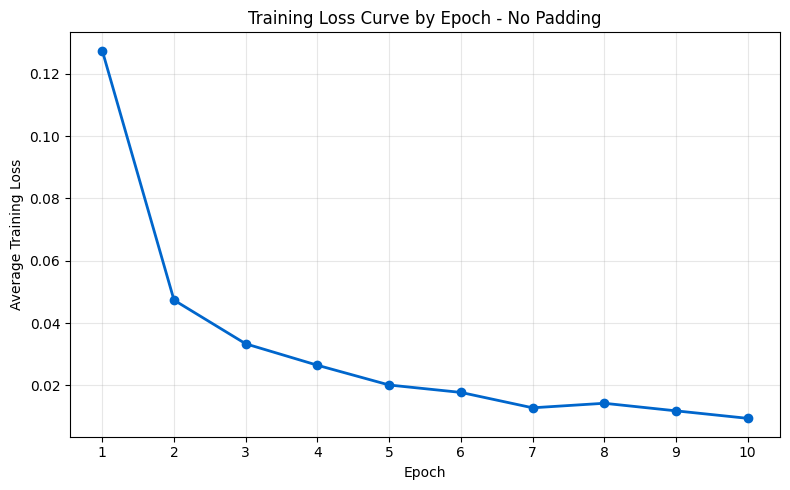

In [25]:
# Epoch별 Training Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_loss_history) + 1), epoch_loss_history,
         marker='o', linewidth=2, color='#0066CC')
plt.title(f'Training Loss Curve by Epoch - {EXPERIMENT_NAME}')
plt.xlabel('Epoch')
plt.ylabel('Average Training Loss')
plt.xticks(range(1, len(epoch_loss_history) + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization 2. Parameters vs Accuracy Scatter Plot
모델의 학습 가능한 파라미터 수와 테스트 정확도를 함께 표시하여 성능 대비 모델 크기를 확인한다.


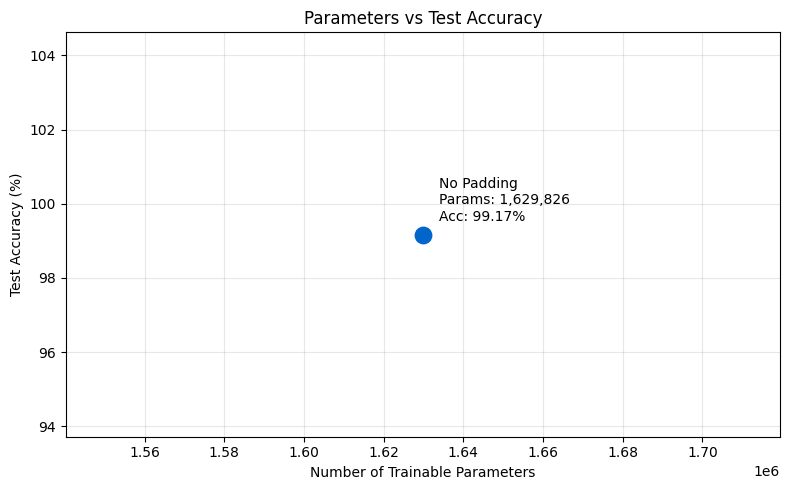

In [26]:
# Parameters vs Accuracy Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(parameter_count, test_accuracy, s=140, color='#0066CC')
plt.annotate(f'{EXPERIMENT_NAME}\nParams: {parameter_count:,}\nAcc: {test_accuracy:.2f}%',
             (parameter_count, test_accuracy),
             textcoords='offset points', xytext=(12, 10), ha='left')
plt.title('Parameters vs Test Accuracy')
plt.xlabel('Number of Trainable Parameters')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
# Model Save
MODEL_PATH = os.path.join(RESULT_DIR, f'{EXPERIMENT_SLUG}.pt')
torch.save(model.state_dict(), MODEL_PATH)
print('Saved model to:', MODEL_PATH)


Saved model to: /content/drive/MyDrive/experiment_results/no_padding.pt


In [28]:
!nvidia-smi

Sat May 16 16:03:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             44W /   70W |    2021MiB /  15360MiB |     35%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----